# Experiment 3 Analysis: Repair Quality vs. Epsilon

This notebook provides a detailed analysis of the repair process for synthetic datasets generated with varying levels of Differential Privacy (Epsilon). We compare three Vertex Cover (VC) based repair algorithms:
1. **Vanilla VC**: Max-degree based vertex selection.
2. **Classic VC**: Random edge-based vertex selection.
3. **Weighted VC**: Frequency-weighted selection (optimized for marginal preservation).

## Objectives
- Analyze the relationship between **Epsilon** and **Violation Count**.
- Compare the **Deletion Ratio** across repair algorithms.
- Evaluate the **Utility Trade-off** (ML Accuracy, TVD, Marginals Error) after repair.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Load aggregated results
summary_path = "../output/experiment_3_summary.csv"
df = pd.read_csv(summary_path)

# Preprocessing: Clean data and average across seeds
df = df.replace([np.inf, -np.inf], np.nan)
avg_df = df.groupby(["dataset", "synthesizer", "epsilon", "repair_algorithm"]).mean(numeric_only=True).reset_index()

# Ensure metrics exist before plotting
avg_df = avg_df.dropna(subset=["deletion_ratio"])

print(f"Loaded {len(df)} individual results.")
print(f"Aggregated into {len(avg_df)} unique configurations.")
avg_df.head()

Loaded 158 individual results.
Aggregated into 33 unique configurations.


,dataset,synthesizer,epsilon,repair_algorithm,job_id,seed,deletion_ratio,tvd_synthetic,tvd_repaired,marginals_error_synthetic,marginals_error_repaired,loss_marginal_synthetic,loss_marginal_repaired,violations_synthetic,violations_repaired,ml_acc_synthetic,ml_acc_repaired
0,adult,aim,0.3,classic_vc,8.0,208.4,0.15008,0.054172,0.067933,0.800818,0.826905,0.013426,0.013444,359005.2,0.0,0.830092,0.831436
1,adult,aim,0.3,vanilla_vc,7.0,208.4,0.07912,0.054172,0.059965,0.800818,0.818850,0.013426,0.013424,359005.2,0.0,0.830090,0.834966
2,adult,aim,0.3,weighted_vc,9.0,208.4,0.08824,0.054172,0.061050,0.800818,0.725449,0.013426,0.012054,359005.2,0.0,0.830090,0.832413
3,adult,aim,0.4,classic_vc,23.0,208.4,0.10776,0.051582,0.059402,0.345657,0.344941,0.011058,0.011552,254964.2,0.0,0.826622,0.828103
4,adult,aim,0.4,vanilla_vc,22.0,208.4,0.05552,0.051582,0.054540,0.345657,0.346852,0.011058,0.011501,254964.2,0.0,0.826622,0.828362


## 1. The Violation Explosion
Lower epsilon (higher noise) leads to more violations. This chart shows the initial state of the synthetic data before repair.

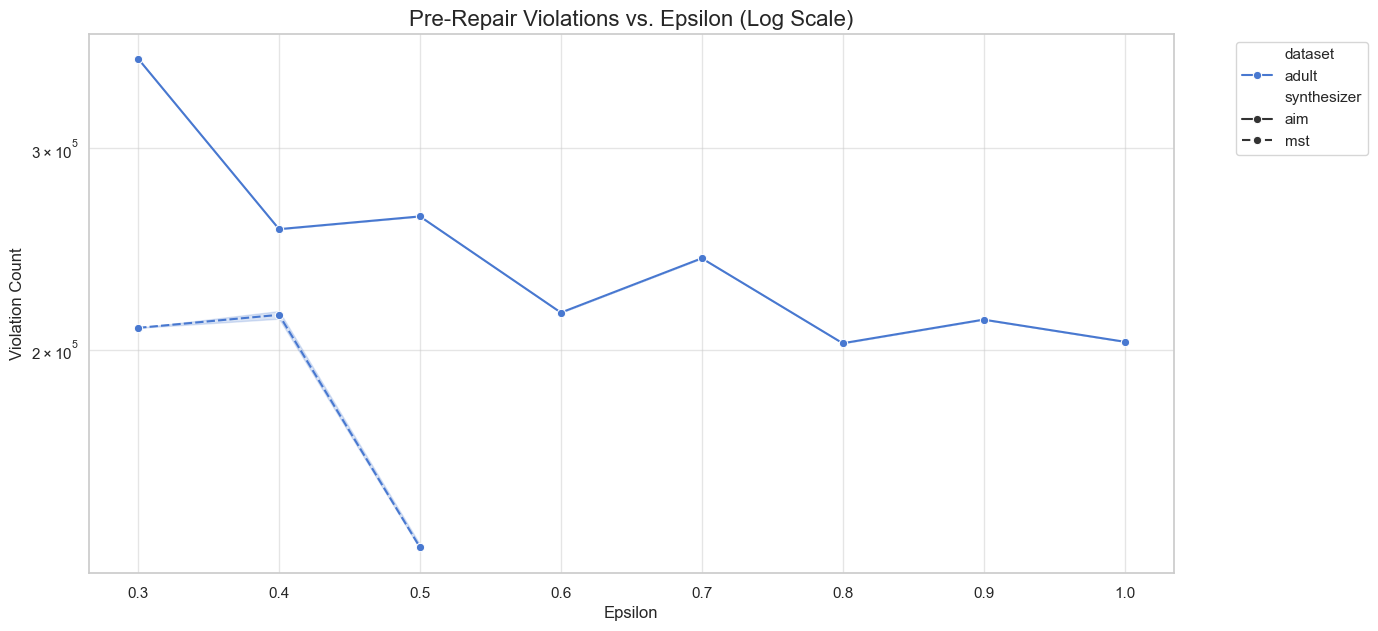

In [26]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=avg_df, x="epsilon", y="violations_synthetic", hue="dataset", style="synthesizer", marker="o")
plt.yscale("log")
plt.title("Pre-Repair Violations vs. Epsilon (Log Scale)", fontsize=16)
plt.ylabel("Violation Count", fontsize=12)
plt.xlabel("Epsilon", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 2. Deletion Ratio vs. Epsilon
How much data do we lose to achieve zero violations?

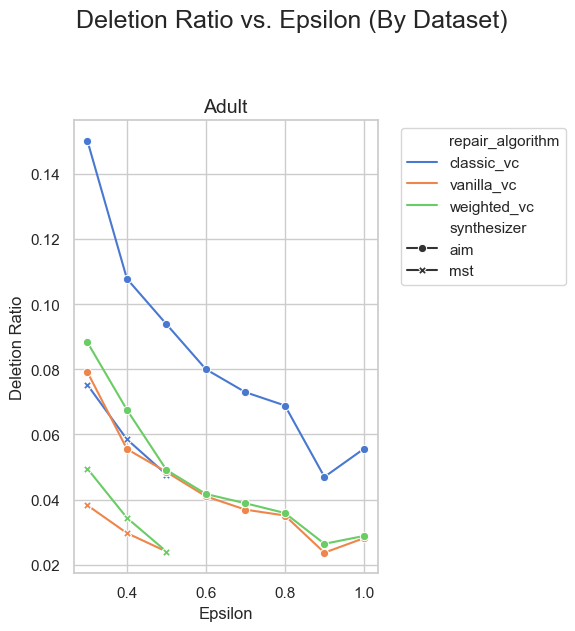

In [27]:
datasets = sorted(avg_df["dataset"].unique())
n_datasets = len(datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(6 * n_datasets, 6), sharey=True)
if n_datasets == 1: axes = [axes]

for i, ds in enumerate(datasets):
    ds_df = avg_df[avg_df["dataset"] == ds]
    sns.lineplot(ax=axes[i], data=ds_df, x="epsilon", y="deletion_ratio", hue="repair_algorithm", style="synthesizer", markers=True, dashes=False)
    axes[i].set_title(f"{ds.capitalize()}", fontsize=14)
    axes[i].set_xlabel("Epsilon")
    if i == 0: axes[i].set_ylabel("Deletion Ratio")
    
    if i != n_datasets - 1: axes[i].get_legend().remove()
    else: axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle("Deletion Ratio vs. Epsilon (By Dataset)", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

## 3. Data Quality: TVD (Total Variation Distance)
Distribution shift caused by the repair process.

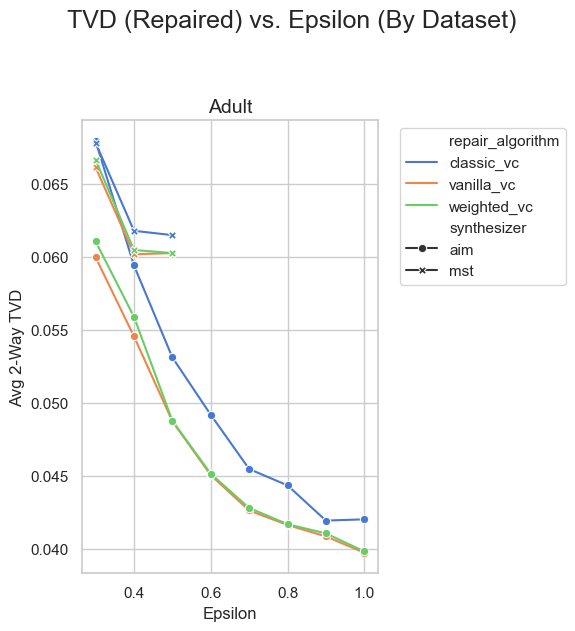

In [28]:
fig, axes = plt.subplots(1, n_datasets, figsize=(6 * n_datasets, 6), sharey=True)
if n_datasets == 1: axes = [axes]

for i, ds in enumerate(datasets):
    ds_df = avg_df[avg_df["dataset"] == ds]
    sns.lineplot(ax=axes[i], data=ds_df, x="epsilon", y="tvd_repaired", hue="repair_algorithm", style="synthesizer", markers=True, dashes=False)
    axes[i].set_title(f"{ds.capitalize()}", fontsize=14)
    axes[i].set_xlabel("Epsilon")
    if i == 0: axes[i].set_ylabel("Avg 2-Way TVD")
    
    if i != n_datasets - 1: axes[i].get_legend().remove()
    else: axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle("TVD (Repaired) vs. Epsilon (By Dataset)", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

## 4. Marginals Preservation: Relative Error
How well does the repair preserve 1-way and 2-way marginal counts?

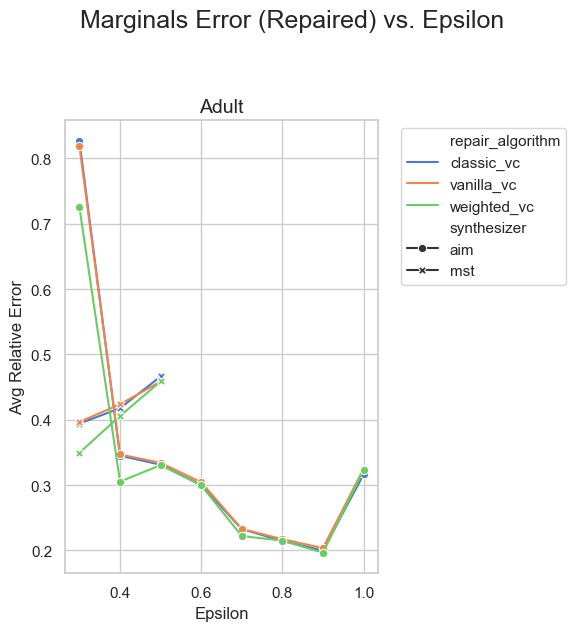

In [29]:
fig, axes = plt.subplots(1, n_datasets, figsize=(6 * n_datasets, 6), sharey=True)
if n_datasets == 1: axes = [axes]

for i, ds in enumerate(datasets):
    ds_df = avg_df[avg_df["dataset"] == ds]
    sns.lineplot(ax=axes[i], data=ds_df, x="epsilon", y="marginals_error_repaired", hue="repair_algorithm", style="synthesizer", markers=True, dashes=False)
    axes[i].set_title(f"{ds.capitalize()}", fontsize=14)
    axes[i].set_xlabel("Epsilon")
    if i == 0: axes[i].set_ylabel("Avg Relative Error")
    
    if i != n_datasets - 1: axes[i].get_legend().remove()
    else: axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle("Marginals Error (Repaired) vs. Epsilon", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

## 5. Optimal Repair Loss: Marginal Component
Absolute error in marginal counts.

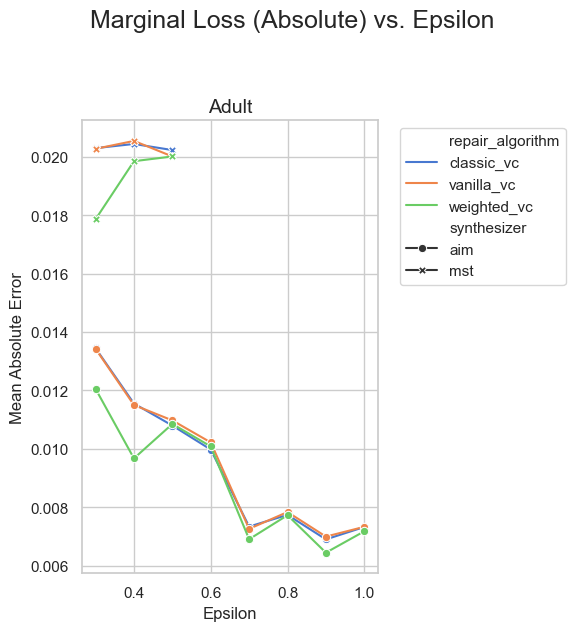

In [30]:
fig, axes = plt.subplots(1, n_datasets, figsize=(6 * n_datasets, 6), sharey=True)
if n_datasets == 1: axes = [axes]

for i, ds in enumerate(datasets):
    ds_df = avg_df[avg_df["dataset"] == ds]
    sns.lineplot(ax=axes[i], data=ds_df, x="epsilon", y="loss_marginal_repaired", hue="repair_algorithm", style="synthesizer", markers=True, dashes=False)
    axes[i].set_title(f"{ds.capitalize()}", fontsize=14)
    axes[i].set_xlabel("Epsilon")
    if i == 0: axes[i].set_ylabel("Mean Absolute Error")
    
    if i != n_datasets - 1: axes[i].get_legend().remove()
    else: axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle("Marginal Loss (Absolute) vs. Epsilon", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

## 6. ML Accuracy Preservation
Preservation of predictive utility compared to the pre-repair baseline.

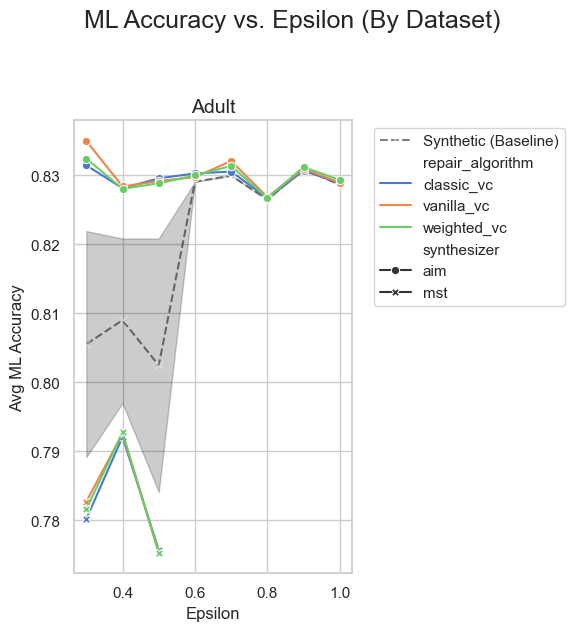

In [31]:
fig, axes = plt.subplots(1, n_datasets, figsize=(6 * n_datasets, 6), sharey=True)
if n_datasets == 1: axes = [axes]

for i, ds in enumerate(datasets):
    ds_df = avg_df[avg_df["dataset"] == ds]
    sns.lineplot(ax=axes[i], data=ds_df, x="epsilon", y="ml_acc_synthetic", label="Synthetic (Baseline)", color="black", linestyle="--", marker="x", alpha=0.5)
    sns.lineplot(ax=axes[i], data=ds_df, x="epsilon", y="ml_acc_repaired", hue="repair_algorithm", style="synthesizer", markers=True, dashes=False)
    axes[i].set_title(f"{ds.capitalize()}", fontsize=14)
    axes[i].set_xlabel("Epsilon")
    if i == 0: axes[i].set_ylabel("Avg ML Accuracy")
    
    if i != n_datasets - 1: axes[i].get_legend().remove()
    else: axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle("ML Accuracy vs. Epsilon (By Dataset)", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
df[(df["repair_algorithm"] == "weighted_vc") & (df["dataset"] != "census")]

,job_id,dataset,synthesizer,epsilon,seed,repair_algorithm,deletion_ratio,tvd_synthetic,tvd_repaired,marginals_error_synthetic,marginals_error_repaired,loss_marginal_synthetic,loss_marginal_repaired,violations_synthetic,violations_repaired,ml_acc_synthetic,ml_acc_repaired
10,3,adult,aim,0.3,42,weighted_vc,0.0792,0.054148,0.060070,0.712519,0.733301,0.013715,0.013608,345020,0,0.832057,0.834221
11,6,adult,aim,0.3,100,weighted_vc,0.0792,0.053966,0.060058,0.863131,0.873419,0.013015,0.012901,377570,0,0.831238,0.834787
12,9,adult,aim,0.3,200,weighted_vc,0.1004,0.053935,0.062096,0.812737,0.604739,0.014227,0.010487,368951,0,0.829314,0.830522
13,12,adult,aim,0.3,300,weighted_vc,0.0888,0.054700,0.062148,0.767932,0.706576,0.012599,0.011799,352025,0,0.829273,0.832405
14,15,adult,aim,0.3,400,weighted_vc,0.0936,0.054112,0.060876,0.847771,0.709211,0.013575,0.011475,351460,0,0.828570,0.830133
25,18,adult,aim,0.4,42,weighted_vc,0.0752,0.052235,0.057174,0.355880,0.255097,0.011436,0.007411,232927,0,0.829375,0.831013
26,21,adult,aim,0.4,100,weighted_vc,0.0574,0.051552,0.054802,0.361275,0.355186,0.010357,0.010538,242033,0,0.825028,0.826167
27,24,adult,aim,0.4,200,weighted_vc,0.0564,0.052002,0.055167,0.368318,0.374351,0.011306,0.011594,281567,0,0.825314,0.827061
28,27,adult,aim,0.4,300,weighted_vc,0.0880,0.051156,0.057950,0.372118,0.285993,0.011482,0.008089,276840,0,0.825874,0.826427
29,30,adult,aim,0.4,400,weighted_vc,0.0608,0.050963,0.054315,0.270693,0.256147,0.010711,0.010738,241454,0,0.827519,0.829443


: 